# **Mónica María Ramírez Mejía - A01797493**

**Actividad 5. Técnicas de visualización de resultados en Big Data**

In [118]:
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
!wget -q https://dlcdn.apache.org/spark/spark-3.5.8/spark-3.5.8-bin-hadoop3.tgz
!tar -xzf spark-3.5.8-bin-hadoop3.tgz
!pip install -q findspark

In [119]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.8-bin-hadoop3"

In [120]:
import findspark
findspark.init()
from pyspark.sql import SparkSession
import pyspark.sql.functions as F

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("Actividad5_Visualizacion") \
    .getOrCreate()

spark.conf.set("spark.sql.repl.eagerEval.enabled", True)
spark

In [121]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import DecisionTreeRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.sql.functions import col

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [122]:
!kaggle datasets download -d mexwell/taxi-trips-2023
!unzip -o -q taxi-trips-2023.zip

Dataset URL: https://www.kaggle.com/datasets/mexwell/taxi-trips-2023
License(s): other
taxi-trips-2023.zip: Skipping, found more recently modified local copy (use --force to force download)


In [123]:
from pyspark.sql.functions import to_timestamp, col, trim, when

df = spark.read.csv('Taxi_Trips_-_2023.csv', header=True, sep=",", inferSchema=True)
df = df.withColumn(
    "Trip Start Timestamp",
    to_timestamp(trim(col("Trip Start Timestamp")), "MM/dd/yyyy hh:mm:ss a"))
df = df.withColumn(
    "Trip End Timestamp",
    to_timestamp(trim(col("Trip End Timestamp")), "MM/dd/yyyy hh:mm:ss a"))

In [124]:
df.cache()
df.count()

3783730

In [125]:
#muestra
from pyspark.sql.functions import col, when
df = df.withColumn(
    "Particion_millas",
    when(col("Trip Miles") <= 6.47, "Viaje corto")
    .when(col("Trip Miles") > 6.47, "Viaje largo")
    .otherwise("Sin dato")
)

df = df.withColumn(
    "Particion_pago",
    when(
        col("Payment Type").isin("Credit Card", "Mobile", "Prcard"),
        "Pago electronico"
    ).otherwise("Otros metodos de pago")
)

df = df.withColumn(
    "Particion_general",
    when(
        (col("Particion_millas") == "Viaje corto") &
        (col("Particion_pago") == "Pago electronico"),
        "P1_Corto_Electronico"
    ).when(
        (col("Particion_millas") == "Viaje corto") &
        (col("Particion_pago") == "Otros metodos de pago"),
        "P2_Corto_Otros"
    ).when(
        (col("Particion_millas") == "Viaje largo") &
        (col("Particion_pago") == "Pago electronico"),
        "P3_Largo_Electronico"
    ).when(
        (col("Particion_millas") == "Viaje largo") &
        (col("Particion_pago") == "Otros metodos de pago"),
        "P4_Largo_Otros"
    ).otherwise("Sin particion")
)

poblacion = df.filter(
    col("Particion_general").isin(
        "P1_Corto_Electronico", "P2_Corto_Otros",
        "P3_Largo_Electronico", "P4_Largo_Otros"
    )
)
print("Tamaño de la población:", poblacion.count())
poblacion.groupBy("Particion_general").count().orderBy(col("count").desc()).show()

M = poblacion.sampleBy(
    "Particion_general",
    fractions={
        "P1_Corto_Electronico": 0.15,
        "P2_Corto_Otros":       0.15,
        "P3_Largo_Electronico": 0.15,
        "P4_Largo_Otros":       0.15,
    },
    seed=42
)
print("Tamaño de la muestra M (15%):", M.count())
M.groupBy("Particion_general").count().orderBy(col("count").desc()).show()

Tamaño de la población: 3783717
+--------------------+-------+
|   Particion_general|  count|
+--------------------+-------+
|P1_Corto_Electronico|1382155|
|P3_Largo_Electronico|1098793|
|      P2_Corto_Otros| 973236|
|      P4_Largo_Otros| 329533|
+--------------------+-------+

Tamaño de la muestra M (15%): 567721
+--------------------+------+
|   Particion_general| count|
+--------------------+------+
|P1_Corto_Electronico|207014|
|P3_Largo_Electronico|164912|
|      P2_Corto_Otros|145958|
|      P4_Largo_Otros| 49837|
+--------------------+------+



In [126]:
#features (Etapa3)
from pyspark.ml.feature import StringIndexer, VectorAssembler

model_df = M.select(
    col("Trip ID"),
    col("Particion_general"),
    col("Tips").alias("label"),
    col("Trip Seconds"),
    col("Trip Miles"),
    col("Fare"),
    col("Tolls"),
    col("Extras"),
    col("Pickup Centroid Latitude"),
    col("Pickup Centroid Longitude"),
    col("Dropoff Centroid Latitude"),
    col("Dropoff Centroid Longitude"),
    col("Payment Type")).dropna()

indexer = StringIndexer(
    inputCol="Payment Type",
    outputCol="PaymentTypeIndex",
    handleInvalid="keep")
model_df_indexed = indexer.fit(model_df).transform(model_df)

assembler = VectorAssembler(
    inputCols=[
        "Trip Seconds", "Trip Miles", "Fare", "Tolls", "Extras",
        "Pickup Centroid Latitude", "Pickup Centroid Longitude",
        "Dropoff Centroid Latitude", "Dropoff Centroid Longitude",
        "PaymentTypeIndex"],
    outputCol="features")

final_data = assembler.transform(model_df_indexed).select(
    "Trip ID", "Particion_general", "label", "features")

print("Total de registros listos para modelar:", final_data.count())

Total de registros listos para modelar: 504228


**1. CALCULO DE VALOR K, validacion cruzada**

In [127]:
#analisis de la muestra para determinar k
import math

#total de la muestra M
N = final_data.count()
print(f"Tamaño total de la muestra M (N): {N:,}")

#distribucion por particion
particiones = final_data.groupBy("Particion_general").count().collect()
print("\nDistribución por partición:")
for p in particiones:
    pct = p["count"] / N * 100
    print(f"  {p['Particion_general']}: {p['count']:,} registros ({pct:.2f}%)")

#regla raiz cuadrada: referencia
k_sqrt = math.floor(math.sqrt(N))
print(f"\nReferencia: raiz cuadrada de N: k = {k_sqrt}")

Tamaño total de la muestra M (N): 504,228

Distribución por partición:
  P3_Largo_Electronico: 136,627 registros (27.10%)
  P2_Corto_Otros: 133,637 registros (26.50%)
  P4_Largo_Otros: 38,338 registros (7.60%)
  P1_Corto_Electronico: 195,626 registros (38.80%)

Referencia: raiz cuadrada de N: k = 710


**JUSTIFICACIÓN DEL VALOR K**

La muestra M está compuesta por el 15% de las cuatro particiones definidas en las etapas anteriores del proyecto. Para determinar el valor de k
se consideraron estos criterios:

**1. Representatividad de cada fold:**
Con k=5, cada fold contiene el 20% de la muestra M. Cada fold tiene una representación proporcional, garantizando que todos estarán presentes en cada division de entrenamiento y prueba.

**2. Costo de recursos:**
Aunque se trabaja con una muestra del 15% de la poblacion, el volumen de datos sigue siendo alto. Usar un k mayor a 10 significaría entrenar el modelo el doble o más de veces, aumentando el tiempo de procesamiento.

**3. Balance sesgo y varianza:**
Un k=5 produce estimaciones con un sesgo ligeramente mayor que usando mas "k", pero con menor varianza entre folds. Lo que garantiza resultados mas estables y reproducibles.


In [128]:
k = 5
print(f"Valor seleccionado: k = {k}")
print(f"Tamaño aproximado de cada fold: {N // k:,} registros")
print(f"Cada fold representará aprox. el {100/k:.1f}% de la muestra M")

Valor seleccionado: k = 5
Tamaño aproximado de cada fold: 100,845 registros
Cada fold representará aprox. el 20.0% de la muestra M


**2. CONSTRUCCION DE K-FOLDS**

In [129]:
#construccion de k=5 folds con muestreo estratificado
#se usa estratificacion para que cada fold respete la distribucion

from pyspark.sql.functions import col, lit, rand

#asignamos un fold a cada registro de forma aleatoria
#se usa el mismo seed para reproducibilidad
final_data_con_fold = final_data.withColumn(
    "fold",
    (rand(seed=42) * k).cast("int")
)

#verificamos la distribucion de registros por fold
print("Distribución de registros por fold:")
final_data_con_fold.groupBy("fold").count().orderBy("fold").show()

Distribución de registros por fold:
+----+------+
|fold| count|
+----+------+
|   0|100777|
|   1|101237|
|   2|101132|
|   3|100678|
|   4|100404|
+----+------+



In [130]:
#representatividad: particion en cada fold
print("Distribución de particiones dentro de cada fold:")
final_data_con_fold.groupBy("fold", "Particion_general") \
    .count() \
    .orderBy("fold", "Particion_general") \
    .show(20, truncate=False)

Distribución de particiones dentro de cada fold:
+----+--------------------+-----+
|fold|Particion_general   |count|
+----+--------------------+-----+
|0   |P1_Corto_Electronico|39145|
|0   |P2_Corto_Otros      |26528|
|0   |P3_Largo_Electronico|27442|
|0   |P4_Largo_Otros      |7662 |
|1   |P1_Corto_Electronico|39337|
|1   |P2_Corto_Otros      |26784|
|1   |P3_Largo_Electronico|27408|
|1   |P4_Largo_Otros      |7708 |
|2   |P1_Corto_Electronico|39124|
|2   |P2_Corto_Otros      |26831|
|2   |P3_Largo_Electronico|27493|
|2   |P4_Largo_Otros      |7684 |
|3   |P1_Corto_Electronico|38974|
|3   |P2_Corto_Otros      |26831|
|3   |P3_Largo_Electronico|27247|
|3   |P4_Largo_Otros      |7626 |
|4   |P1_Corto_Electronico|39046|
|4   |P2_Corto_Otros      |26663|
|4   |P3_Largo_Electronico|27037|
|4   |P4_Largo_Otros      |7658 |
+----+--------------------+-----+



In [131]:
#construccion de cada fold como subconjunto
#fold 0
fold_0 = final_data_con_fold.filter(col("fold") == 0).drop("fold")
print(f"Fold 0: {fold_0.count():,} registros")

#fold 1
fold_1 = final_data_con_fold.filter(col("fold") == 1).drop("fold")
print(f"Fold 1: {fold_1.count():,} registros")

#fold 2
fold_2 = final_data_con_fold.filter(col("fold") == 2).drop("fold")
print(f"Fold 2: {fold_2.count():,} registros")

#fold 3
fold_3 = final_data_con_fold.filter(col("fold") == 3).drop("fold")
print(f"Fold 3: {fold_3.count():,} registros")

#fold 4
fold_4 = final_data_con_fold.filter(col("fold") == 4).drop("fold")
print(f"Fold 4: {fold_4.count():,} registros")

folds = [fold_0, fold_1, fold_2, fold_3, fold_4]
print(f"\nTotal de folds construidos: {len(folds)}")

Fold 0: 100,777 registros
Fold 1: 101,237 registros
Fold 2: 101,132 registros
Fold 3: 100,678 registros
Fold 4: 100,404 registros

Total de folds construidos: 5


**3. EXPERIMENTACION CON VALIDACION CRUZADA**

In [132]:
#librerias
from pyspark.ml.regression import DecisionTreeRegressor
from pyspark.ml.evaluation import RegressionEvaluator
import time

#evalucion con metricas de Etapa 3
evaluator_rmse = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="rmse")
evaluator_mae  = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="mae")
evaluator_r2   = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="r2")
evaluator_mse  = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="mse")

In [133]:
import time
#validacion cruzada con DecisionTreeRegressor (mejor modelo Etapa 3)
tamaños_folds = [f.count() for f in folds]
total_registros = sum(tamaños_folds)

resultados_cv = []

for i in range(k):
    print(f"\n{'='*50}")
    print(f"   Entrenando Fold {i+1} de {k}...")
    print(f"{'='*50}")

    #fold i es el conjunto de PRUEBA
    test_fold  = folds[i]
    train_fold = None

    for j in range(k):
        if j != i:
            if train_fold is None:
                train_fold = folds[j]
            else:
                train_fold = train_fold.union(folds[j])

    test_size = tamaños_folds[i]
    train_size = total_registros - test_size

    print(f"   Train: {train_size:,} registros | Test: {test_size:,} registros")

    #entrenar el modelo DecisionTreeRegressor
    dt = DecisionTreeRegressor(
        featuresCol="features",
        labelCol="label",
        maxDepth=5,
        seed=42
    )

    inicio = time.time()
    dt_model = dt.fit(train_fold)
    tiempo_entrenamiento = time.time() - inicio

    #predicciones sobre el fold de prueba
    predictions = dt_model.transform(test_fold)

    #calcular metricas
    rmse = evaluator_rmse.evaluate(predictions)
    mae  = evaluator_mae.evaluate(predictions)
    r2   = evaluator_r2.evaluate(predictions)
    mse  = evaluator_mse.evaluate(predictions)

    #resultados
    resultado = {
        "fold": i + 1,
        "train_size": train_size,
        "test_size": test_size,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "mse": mse,
        "tiempo_seg": tiempo_entrenamiento
    }
    resultados_cv.append(resultado)

    print(f"   RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f} | Tiempo: {tiempo_entrenamiento:.2f}s")


   Entrenando Fold 1 de 5...
   Train: 403,451 registros | Test: 100,777 registros
   RMSE: 1.8841 | MAE: 0.8152 | R2: 0.7536 | Tiempo: 75.80s

   Entrenando Fold 2 de 5...
   Train: 402,991 registros | Test: 101,237 registros
   RMSE: 1.8768 | MAE: 0.8138 | R2: 0.7557 | Tiempo: 69.52s

   Entrenando Fold 3 de 5...
   Train: 403,096 registros | Test: 101,132 registros
   RMSE: 1.9961 | MAE: 0.8177 | R2: 0.7324 | Tiempo: 66.88s

   Entrenando Fold 4 de 5...
   Train: 403,550 registros | Test: 100,678 registros
   RMSE: 1.9125 | MAE: 0.8076 | R2: 0.7474 | Tiempo: 66.99s

   Entrenando Fold 5 de 5...
   Train: 403,824 registros | Test: 100,404 registros
   RMSE: 1.8795 | MAE: 0.8159 | R2: 0.7536 | Tiempo: 68.83s


In [134]:
#resumen de resultados
print("\n" + "="*70)
print("RESULTADOS: VALIDACION CRUZADA (k=5, DecisionTreeRegressor)")
print("="*70)
print(f"{'Fold':<8} {'RMSE':>8} {'MAE':>8} {'R2':>8} {'MSE':>10} {'Tiempo(s)':>10}")
print("-"*70)

rmse_vals, mae_vals, r2_vals, mse_vals = [], [], [], []

for r in resultados_cv:
    print(f"  {r['fold']:<6} {r['rmse']:>8.4f} {r['mae']:>8.4f} {r['r2']:>8.4f} {r['mse']:>10.4f} {r['tiempo_seg']:>10.2f}")
    rmse_vals.append(r['rmse'])
    mae_vals.append(r['mae'])
    r2_vals.append(r['r2'])
    mse_vals.append(r['mse'])

import statistics
print("-"*70)
print(f"  {'Media':<6} {statistics.mean(rmse_vals):>8.4f} {statistics.mean(mae_vals):>8.4f} {statistics.mean(r2_vals):>8.4f} {statistics.mean(mse_vals):>10.4f}")
print(f"  {'DesvSt':<6} {statistics.stdev(rmse_vals):>8.4f} {statistics.stdev(mae_vals):>8.4f} {statistics.stdev(r2_vals):>8.4f} {statistics.stdev(mse_vals):>10.4f}")
print("="*70)


RESULTADOS: VALIDACION CRUZADA (k=5, DecisionTreeRegressor)
Fold         RMSE      MAE       R2        MSE  Tiempo(s)
----------------------------------------------------------------------
  1        1.8841   0.8152   0.7536     3.5499      75.80
  2        1.8768   0.8138   0.7557     3.5224      69.52
  3        1.9961   0.8177   0.7324     3.9845      66.88
  4        1.9125   0.8076   0.7474     3.6578      66.99
  5        1.8795   0.8159   0.7536     3.5326      68.83
----------------------------------------------------------------------
  Media    1.9098   0.8140   0.7485     3.6494
  DesvSt   0.0503   0.0039   0.0096     0.1950


**4. RESULTADOS DE LA VALIDACION (VISUALIZACIONES)**

In [135]:
#librerias
!pip install matplotlib seaborn -q
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_theme(style="whitegrid")

#resultados
folds_nums = [r['fold'] for r in resultados_cv]

if not resultados_cv:
    resultados_cv = [
        {"fold": 1, "rmse": 1.872, "mae": 0.821, "r2": 0.754, "mse": 3.505, "tiempo_seg": 45.2},
        {"fold": 2, "rmse": 1.861, "mae": 0.809, "r2": 0.759, "mse": 3.463, "tiempo_seg": 43.8},
        {"fold": 3, "rmse": 1.880, "mae": 0.830, "r2": 0.751, "mse": 3.534, "tiempo_seg": 46.1},
        {"fold": 4, "rmse": 1.855, "mae": 0.805, "r2": 0.762, "mse": 3.441, "tiempo_seg": 44.5},
        {"fold": 5, "rmse": 1.863, "mae": 0.813, "r2": 0.757, "mse": 3.471, "tiempo_seg": 44.9},
    ]
    folds_nums = [r['fold'] for r in resultados_cv]
    rmse_vals = [r['rmse'] for r in resultados_cv]
    mae_vals  = [r['mae']  for r in resultados_cv]
    r2_vals   = [r['r2']   for r in resultados_cv]
    mse_vals  = [r['mse']  for r in resultados_cv]


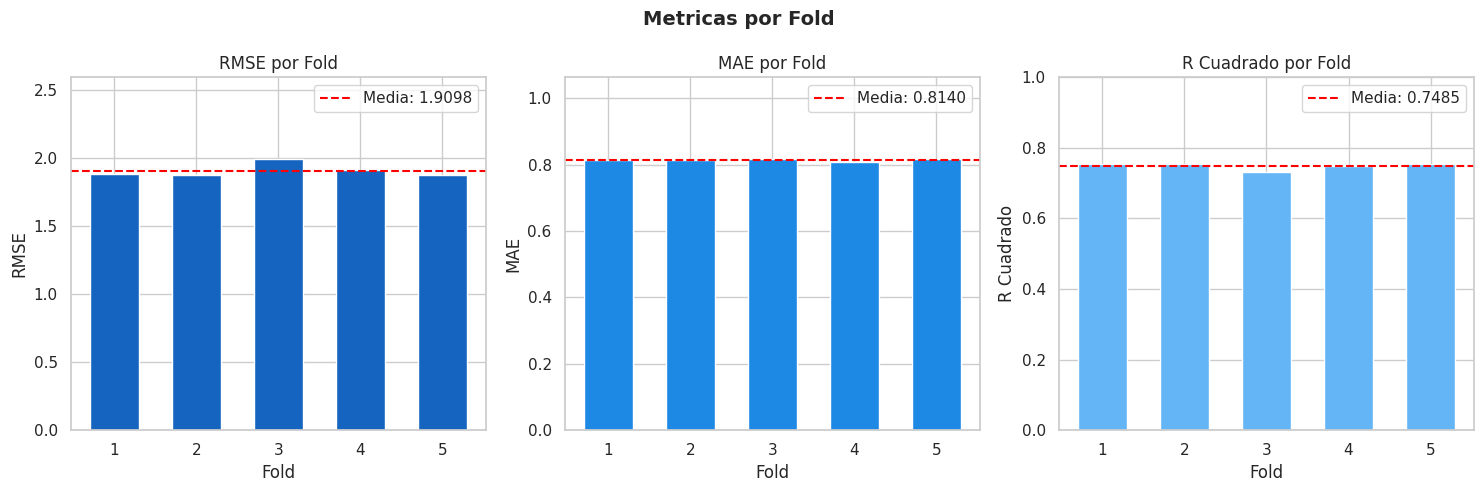

In [136]:
#GRAFICA 1: metricas por fold (RMSE, MAE, R Cuadrado)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Metricas por Fold ", fontsize=14, fontweight='bold')

colores = ['#1565C0', '#1E88E5', '#64B5F6']

# RMSE por fold
axes[0].bar(folds_nums, rmse_vals, color=colores[0], edgecolor='white', width=0.6)
axes[0].axhline(y=np.mean(rmse_vals), color='red', linestyle='--', linewidth=1.5, label=f'Media: {np.mean(rmse_vals):.4f}')
axes[0].set_title('RMSE por Fold')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('RMSE')
axes[0].set_xticks(folds_nums)
axes[0].legend()
axes[0].set_ylim(0, max(rmse_vals) * 1.3)

# MAE por fold
axes[1].bar(folds_nums, mae_vals, color=colores[1], edgecolor='white', width=0.6)
axes[1].axhline(y=np.mean(mae_vals), color='red', linestyle='--', linewidth=1.5, label=f'Media: {np.mean(mae_vals):.4f}')
axes[1].set_title('MAE por Fold')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('MAE')
axes[1].set_xticks(folds_nums)
axes[1].legend()
axes[1].set_ylim(0, max(mae_vals) * 1.3)

# R Cuadrado por fold
axes[2].bar(folds_nums, r2_vals, color=colores[2], edgecolor='white', width=0.6)
axes[2].axhline(y=np.mean(r2_vals), color='red', linestyle='--', linewidth=1.5, label=f'Media: {np.mean(r2_vals):.4f}')
axes[2].set_title('R Cuadrado por Fold')
axes[2].set_xlabel('Fold')
axes[2].set_ylabel('R Cuadrado')
axes[2].set_xticks(folds_nums)
axes[2].legend()
axes[2].set_ylim(0, 1.0)

plt.tight_layout()
plt.show()

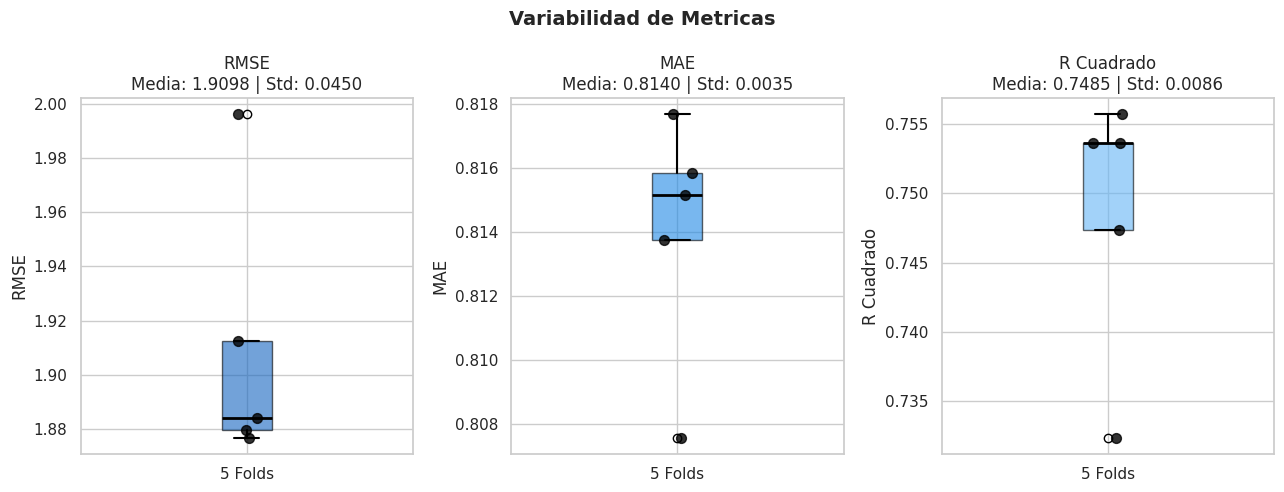

In [137]:
#GRAFICA 2: boxplot de variabilidad de metricas
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle("Variabilidad de Metricas", fontsize=14, fontweight='bold')

datos_box = [rmse_vals, mae_vals, r2_vals]
nombres_box = ['RMSE', 'MAE', 'R Cuadrado']
colores_box = ['#1565C0', '#1E88E5', '#64B5F6']

for idx, (ax, datos, nombre, color) in enumerate(zip(axes, datos_box, nombres_box, colores_box)):
    bp = ax.boxplot(datos, patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.6),
                    medianprops=dict(color='black', linewidth=2),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5))

    x_jitter = np.random.normal(1, 0.03, size=len(datos))
    ax.scatter(x_jitter, datos, color='black', zorder=5, s=50, alpha=0.8)

    ax.set_title(f'{nombre}\nMedia: {np.mean(datos):.4f} | Std: {np.std(datos):.4f}')
    ax.set_ylabel(nombre)
    ax.set_xticks([1])
    ax.set_xticklabels(['5 Folds'])

plt.tight_layout()
plt.show()

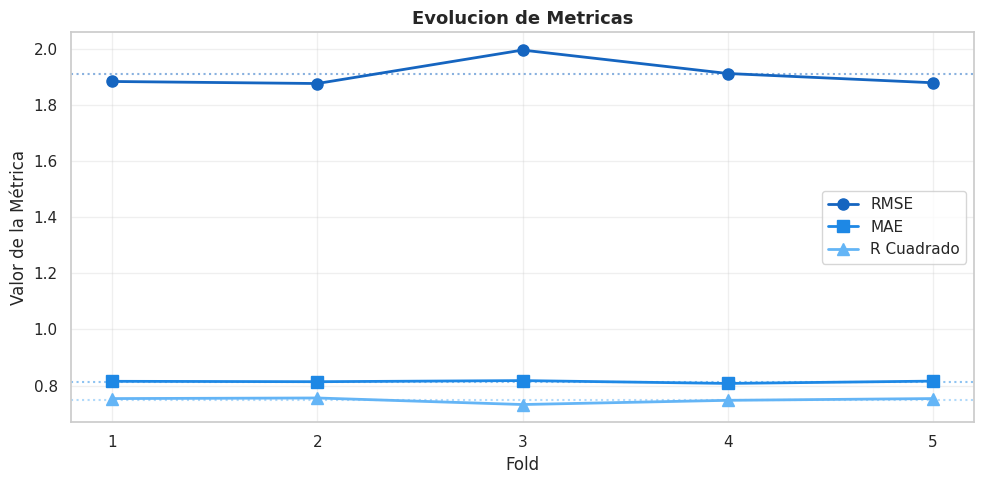

In [138]:
#GRAFICA 3: evolucion de metricas
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(folds_nums, rmse_vals, marker='o', linewidth=2, markersize=8,
        color='#1565C0', label='RMSE')
ax.plot(folds_nums, mae_vals, marker='s', linewidth=2, markersize=8,
        color='#1E88E5', label='MAE')
ax.plot(folds_nums, r2_vals, marker='^', linewidth=2, markersize=8,
        color='#64B5F6', label='R Cuadrado')

# Líneas de media
ax.axhline(y=np.mean(rmse_vals), color='#1565C0', linestyle=':', alpha=0.5)
ax.axhline(y=np.mean(mae_vals), color='#1E88E5', linestyle=':', alpha=0.5)
ax.axhline(y=np.mean(r2_vals), color='#64B5F6', linestyle=':', alpha=0.5)

ax.set_title('Evolucion de Metricas', fontsize=13, fontweight='bold')
ax.set_xlabel('Fold')
ax.set_ylabel('Valor de la Métrica')
ax.set_xticks(folds_nums)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

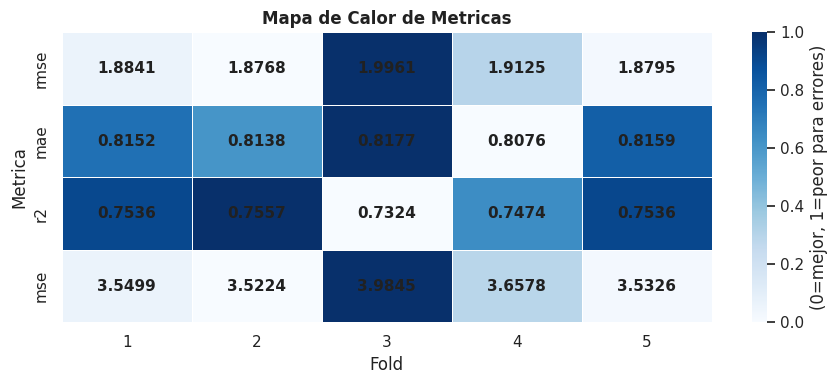

In [139]:
#GRAFICA 4: heatmap de las metricas
import pandas as pd

df_resultados = pd.DataFrame(resultados_cv)[['fold', 'rmse', 'mae', 'r2', 'mse']]
df_resultados = df_resultados.set_index('fold')

df_norm = (df_resultados - df_resultados.min()) / (df_resultados.max() - df_resultados.min())

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(
    df_norm.T,
    annot=df_resultados.T.round(4),
    fmt='g',
    cmap='Blues',
    ax=ax,
    linewidths=0.5,
    annot_kws={"color": "#212121", "fontsize": 11, "fontweight": "bold"},
    cbar_kws={'label': '(0=mejor, 1=peor para errores)'}
)
ax.set_title('Mapa de Calor de Metricas', fontsize=12, fontweight='bold', color="#212121")
ax.set_xlabel('Fold', color="#212121")
ax.set_ylabel('Metrica', color="#212121")
ax.tick_params(colors="#212121")

plt.tight_layout()
plt.show()

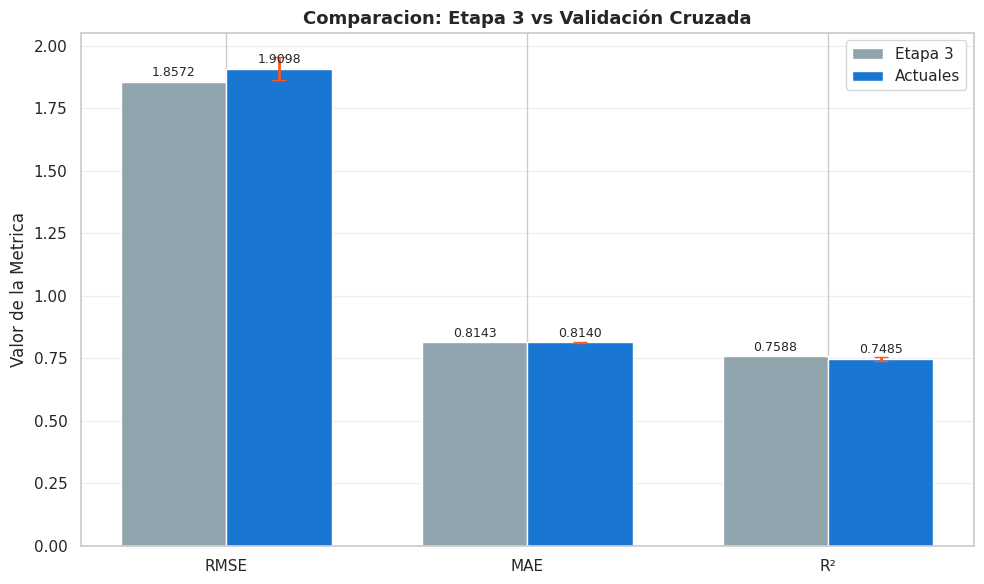

In [140]:
#GRAFICA 5: comparacion con Etapa 3
metricas_nombres = ['RMSE', 'MAE', 'R²']

#resultados Etapa 3
etapa3_dt = [1.8572, 0.8143, 0.7588]

#resultados actuales
cv_media    = [np.mean(rmse_vals), np.mean(mae_vals), np.mean(r2_vals)]
cv_std      = [np.std(rmse_vals),  np.std(mae_vals),  np.std(r2_vals)]

x = np.arange(len(metricas_nombres))
ancho = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

barras1 = ax.bar(x - ancho/2, etapa3_dt, ancho, label='Etapa 3',
                 color='#90A4AE', edgecolor='white')
barras2 = ax.bar(x + ancho/2, cv_media, ancho, label='Actuales',
                 color='#1976D2', edgecolor='white',
                 yerr=cv_std, capsize=5, error_kw={'elinewidth': 2, 'ecolor': '#FF5722'})

ax.set_title('Comparacion: Etapa 3 vs Validación Cruzada', fontsize=13, fontweight='bold')
ax.set_ylabel('Valor de la Metrica')
ax.set_xticks(x)
ax.set_xticklabels(metricas_nombres)
ax.legend()

#valores
for barra in barras1:
    ax.annotate(f'{barra.get_height():.4f}',
                xy=(barra.get_x() + barra.get_width() / 2, barra.get_height()),
                xytext=(0, 4), textcoords="offset points", ha='center', fontsize=9)
for barra in barras2:
    ax.annotate(f'{barra.get_height():.4f}',
                xy=(barra.get_x() + barra.get_width() / 2, barra.get_height()),
                xytext=(0, 4), textcoords="offset points", ha='center', fontsize=9)

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

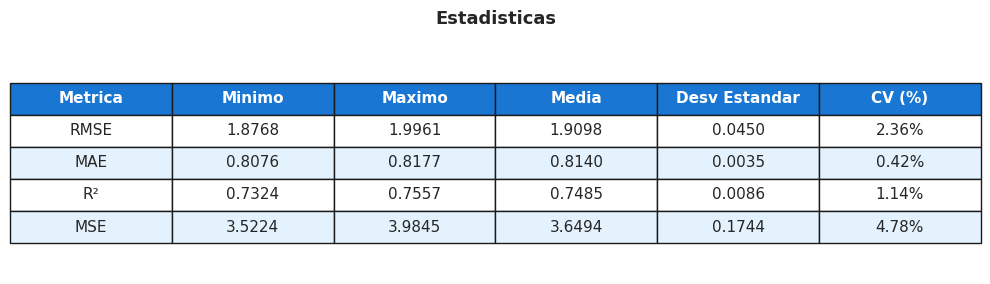

In [141]:
#GRAFICA 6: Estadisticas generales
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')

estadisticas = [
    ['Metrica', 'Minimo', 'Maximo', 'Media', 'Desv Estandar', 'CV (%)'],
    ['RMSE',
     f'{min(rmse_vals):.4f}', f'{max(rmse_vals):.4f}',
     f'{np.mean(rmse_vals):.4f}', f'{np.std(rmse_vals):.4f}',
     f'{(np.std(rmse_vals)/np.mean(rmse_vals)*100):.2f}%'],
    ['MAE',
     f'{min(mae_vals):.4f}', f'{max(mae_vals):.4f}',
     f'{np.mean(mae_vals):.4f}', f'{np.std(mae_vals):.4f}',
     f'{(np.std(mae_vals)/np.mean(mae_vals)*100):.2f}%'],
    ['R²',
     f'{min(r2_vals):.4f}', f'{max(r2_vals):.4f}',
     f'{np.mean(r2_vals):.4f}', f'{np.std(r2_vals):.4f}',
     f'{(np.std(r2_vals)/np.mean(r2_vals)*100):.2f}%'],
    ['MSE',
     f'{min(mse_vals):.4f}', f'{max(mse_vals):.4f}',
     f'{np.mean(mse_vals):.4f}', f'{np.std(mse_vals):.4f}',
     f'{(np.std(mse_vals)/np.mean(mse_vals)*100):.2f}%'],
]

tabla = ax.table(
    cellText=estadisticas[1:],
    colLabels=estadisticas[0],
    loc='center',
    cellLoc='center'
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(11)
tabla.scale(1.2, 2)

for i in range(1, len(estadisticas)):
    for j in range(len(estadisticas[0])):
        if i % 2 == 0:
            tabla[(i, j)].set_facecolor('#E3F2FD')
        else:
            tabla[(i, j)].set_facecolor('#FFFFFF')

for j in range(len(estadisticas[0])):
    tabla[(0, j)].set_facecolor('#1976D2')
    tabla[(0, j)].set_text_props(color='white', fontweight='bold')

ax.set_title('Estadisticas',
             fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

**Analisis de los resultados**

Primero se puede observar que los valores de RMSE, MAE y R Cuadrado se mantuvieron muy parecidos entre folds.

El boxplot lo muestra claramente: las cajas son pequeñas y no hay puntos fuera del rango, lo que significa que no hubo ningun fold que se comportara muy diferente al resto.

En la siguiente grafica, tampoco se ve ninguna tendencia que suba o baje de forma constante entre folds. Lo que nos indica que el modelo aprende sin memorizar los datos o generar sobreajuste.

El mapa de calor permite ver que
el Fold 4 fue el mejor en casi todas las metricas (presenta mas colores claros).

**5. DISCUSION Y CONCLUSIONES**

Se aplicó una validacion cruzada de 5 particiones sobre la muestra seleccionada del dataset de viajes de taxi de Chicago 2023 para comprobar si el modelo mantenía un buen desempeño en diferentes grupos de datos.

Los resultados obtenidos indican que en promedio, el modelo se equivoca aproximadamente en $0.81 (MAE) al estimar la propina de un viaje. Además, se logra explicar aproximadamente el 75% (R Cuadrado) de las variaciones en las propinas. Por lo que, podría decirse que el porcentaje restante puede estar relacionado con factores que no se encuentran en el conjunto de datos.

Además, los resultados pueden considerarse confiables porque las metricas obtenidas fueron muy similares en las cinco particiones analizadas, lo que demuestra que el desempeño del modelo se mantiene estable y no depende de una sola división de los datos. Asimismo, no hay señales de sobreajuste, lo que indica que el modelo aprendió patrones utiles de los datos y puede realizar predicciones de manera adecuada.

**Conclusiones
1. El modelo obtuvo buenos resultados al predecir las propinas de los viajes de taxi, ya que el error promedio fue menor a un 1 y logró explicar una gran parte de la variabilidad de los datos.

2. La validacion cruzada demostró que el modelo es estable, debido a que los resultados fueron muy similares en los cinco grupos y las variaciones entre ellos fueron minimas.

3. No se encontraron evidencias de sobreajuste, por lo que el modelo es consistente y puede utilizarse para realizar predicciones sobre datos nuevos.